# Cell-level representation learning

This demo runs end-to-end on the **built-in Liu subsample** (~30k cells, 3 batches,
RNA + ADT) — one line to load. It uses the EXACT same parameters as the full-data
tutorial; only the data is subsampled. Use this to learn
the API and feel the workflow. For the full-data version that reproduces the
publication numbers, retrain on the full Liu dataset with the same parameters.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import m3

OUT = "./tutorial_out_demo/01_representation_learning"
os.makedirs(OUT, exist_ok=True)
sc.settings.verbosity = 1

## 1. Load the built-in demo (one line)

`m3.datasets.liu_demo()` returns a ready-to-go `Dataset`:
a stratified subsample of Liu et al. COVID-19.

In [2]:
data = m3.datasets.liu_demo()
print(data)
print("celltypes:", data.obs["mergedcelltype"].value_counts().to_dict())

Dataset(n_cells=30534, batches=['B1', 'B2', 'B3'], modalities=[rna:1000, adt:192])
celltypes: {'CD4_Mem': 5721, 'Mono_Classical': 4119, 'B_Mem': 3884, 'CD8_Mem': 3838, 'NK': 2544, 'CD4_Naive': 1642, 'B_Naive': 1638, 'CD8_Naive': 1598, 'CD8_Va7.2': 1512, 'T_Vd2': 1387, 'Mono_Nonclassical': 1029, 'Plasmablast': 828, 'Platelet': 272, 'T_gd': 250, 'DC': 149, 'Erythrocyte': 88, 'pDC': 35}


/opt/miniforge3/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 2. Build and train the integration model

Pure representation learning — no donor predictor. `batch_key="batch"` names the
obs column of batch labels (B1/B2/B3) that the VAE balances and corrects across.

In [3]:
model = m3.M3(
    data,
    condition_keys=["cond_group", "Age_interval"],
    celltype_key="mergedcelltype",
    batch_key="batch",
    embedding_dim=30,
)
#To save time, users can set max_epochs to 100 for test.
model.train(max_epochs=500, donor_prediction=False)
print("capabilities:", model.capabilities)

Using 'matrix/data'
torch.Size([1000, 7163])
Using 'matrix/data'


torch.Size([1000, 10789])
Using 'matrix/data'
torch.Size([1000, 12582])
Using 'matrix/data'
torch.Size([192, 7163])
Using 'matrix/data'


torch.Size([192, 10789])
Using 'matrix/data'
torch.Size([192, 12582])
Batch counts: {0: 7163, 1: 10789, 2: 12582}
Minimum batch size: 7163


Epoch 1, Validation Loss: 5.1807


Epoch 2, Validation Loss: 5.1167


...

Epoch 499, Validation Loss: 0.5039


Epoch 500, Validation Loss: 0.5011
Using 'matrix/data'
torch.Size([1000, 7163])
Using 'matrix/data'


torch.Size([1000, 10789])
Using 'matrix/data'
torch.Size([1000, 12582])
Using 'matrix/data'


torch.Size([192, 7163])
Using 'matrix/data'
torch.Size([192, 10789])
Using 'matrix/data'
torch.Size([192, 12582])


capabilities: {'embedding': True, 'reconstruct': True, 'predict_donors': False}


## 3. Extract disentangled embeddings

In [4]:
emb_bio = model.embedding(part="bio")
emb_batch = model.embedding(part="batch")
meta = model.cell_metadata.copy()
print("bio:", emb_bio.shape, "batch:", emb_batch.shape)

bio: (30534, 28) batch: (30534, 2)


## 4. Save (npy / h5 / h5ad)

In [5]:
import h5py
import anndata as ad

np.save(os.path.join(OUT, "embedding_bio.npy"), emb_bio)
meta.to_csv(os.path.join(OUT, "cell_metadata.csv"), index=False)
with h5py.File(os.path.join(OUT, "embedding_bio.h5"), "w") as f:
    f["data"] = emb_bio
ad.AnnData(X=emb_bio, obs=meta.astype(str).reset_index(drop=True)).write_h5ad(
    os.path.join(OUT, "embedding_bio.h5ad"))
print("saved -> .npy / .h5 / .h5ad in", OUT)

/opt/miniforge3/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
... storing 'sample_id' as categorical


... storing 'Donor' as categorical


... storing 'cond_group' as categorical


... storing 'Age_interval' as categorical


... storing 'mergedcelltype' as categorical


... storing 'batch' as categorical


saved -> .npy / .h5 / .h5ad in ./tutorial_out_demo/01_representation_learning


## 5. UMAP — bio + batch latent

/opt/miniforge3/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


2026-07-01 11:36:57.335702: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-01 11:36:57.357696: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-01 11:36:57.970598: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


... storing 'sample_id' as categorical


... storing 'Donor' as categorical


... storing 'Age_interval' as categorical


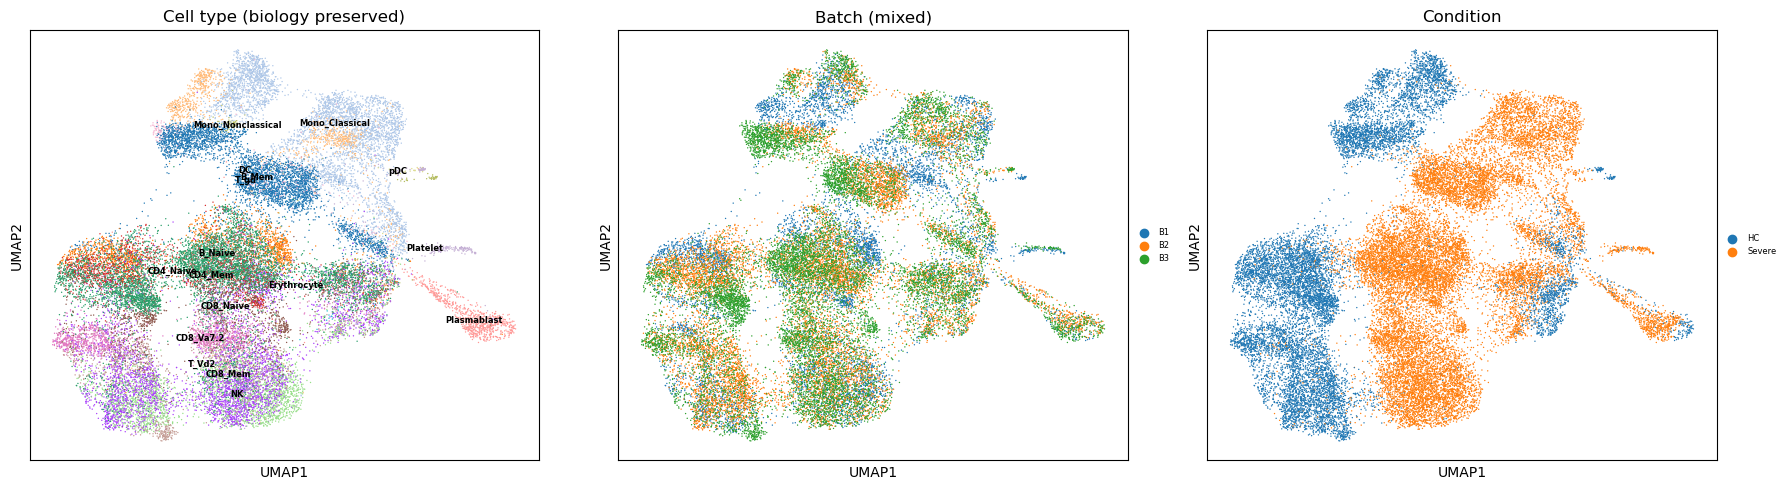

/opt/miniforge3/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


... storing 'sample_id' as categorical


... storing 'Donor' as categorical


... storing 'cond_group' as categorical


... storing 'Age_interval' as categorical


... storing 'mergedcelltype' as categorical


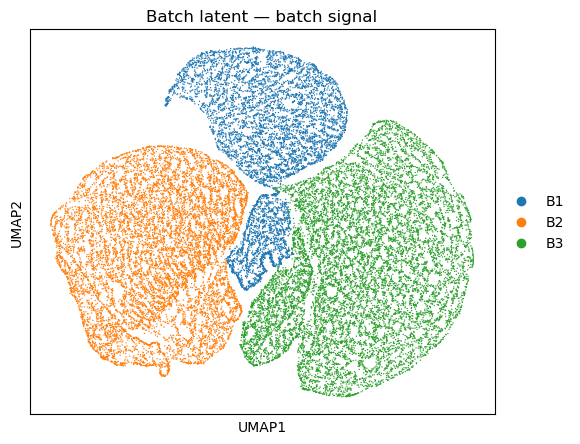

In [6]:
adn = sc.AnnData(X=emb_bio, obs=meta.reset_index(drop=True))
adn.obs["batch"] = adn.obs["batch"].astype("category")
adn.obs["mergedcelltype"] = adn.obs["mergedcelltype"].astype(str).astype("category")
adn.obs["cond_group"] = adn.obs["cond_group"].astype(str).astype("category")
sc.pp.neighbors(adn, use_rep="X", n_neighbors=15)
sc.tl.umap(adn)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key, title in zip(
    axes,
    ["mergedcelltype", "batch", "cond_group"],
    ["Cell type (biology preserved)", "Batch (mixed)", "Condition"],
):
    sc.pl.umap(adn, color=key, ax=ax, show=False, title=title,
               legend_loc="right margin" if key != "mergedcelltype" else "on data",
               legend_fontsize=6)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "umap_bio.png"), dpi=130, bbox_inches="tight")
plt.show()

adn_b = sc.AnnData(X=emb_batch, obs=meta.reset_index(drop=True))
adn_b.obs["batch"] = adn_b.obs["batch"].astype("category")
sc.pp.neighbors(adn_b, use_rep="X", n_neighbors=15)
sc.tl.umap(adn_b)
fig2, ax = plt.subplots(figsize=(6, 5))
sc.pl.umap(adn_b, color="batch", ax=ax, show=False, title="Batch latent — batch signal")
fig2.savefig(os.path.join(OUT, "umap_batch.png"), dpi=130, bbox_inches="tight")
plt.show()

**Done.** Integrated cell embedding ready for clustering / downstream analysis.
Retrain on the full Liu dataset for publication-scale results.